<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB
None
  session_id  network_packet_size protocol_type  login_attempts  \
0  SID_00001                  599           TCP               4   
1  SID_00002                  472       

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

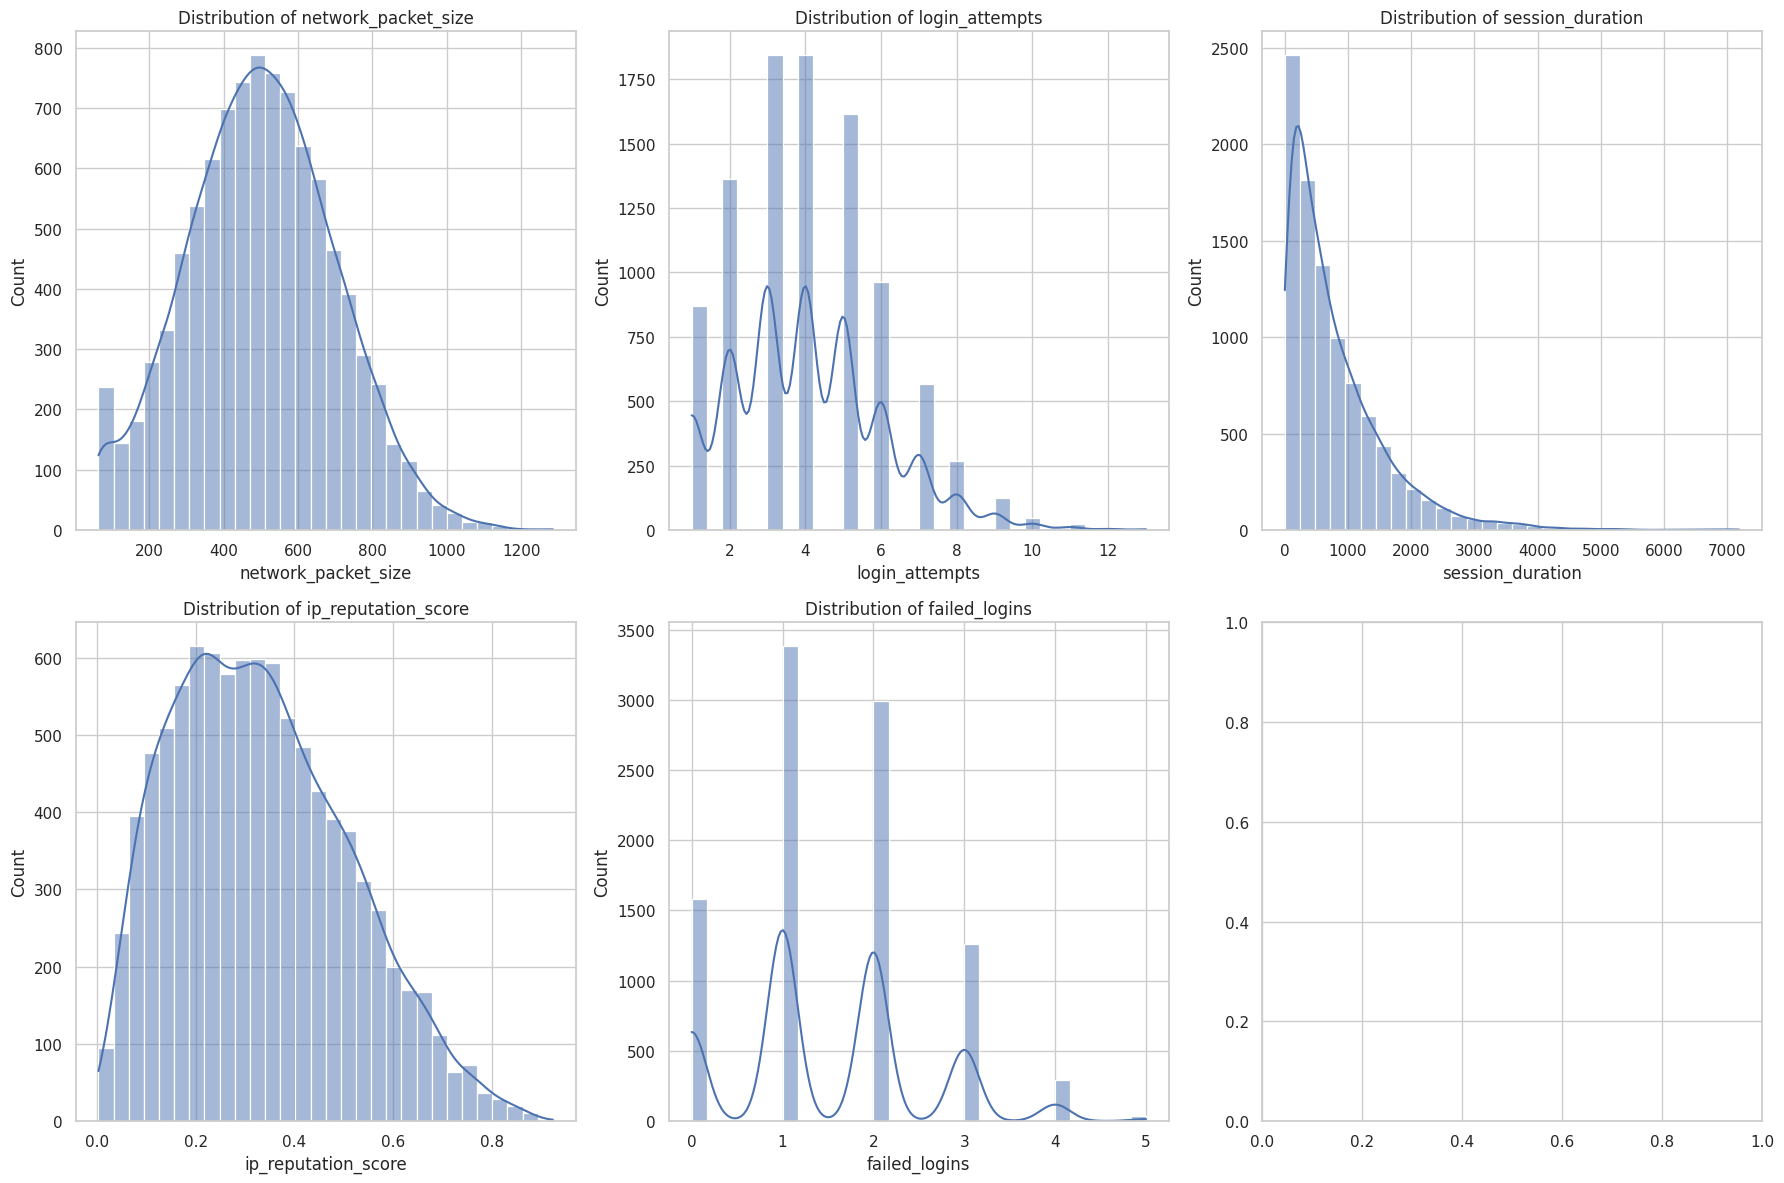

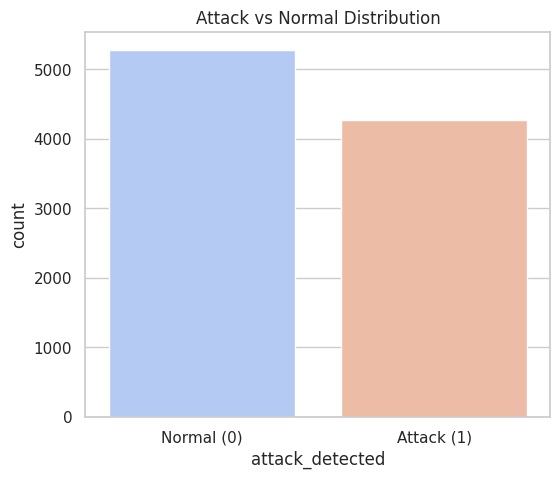

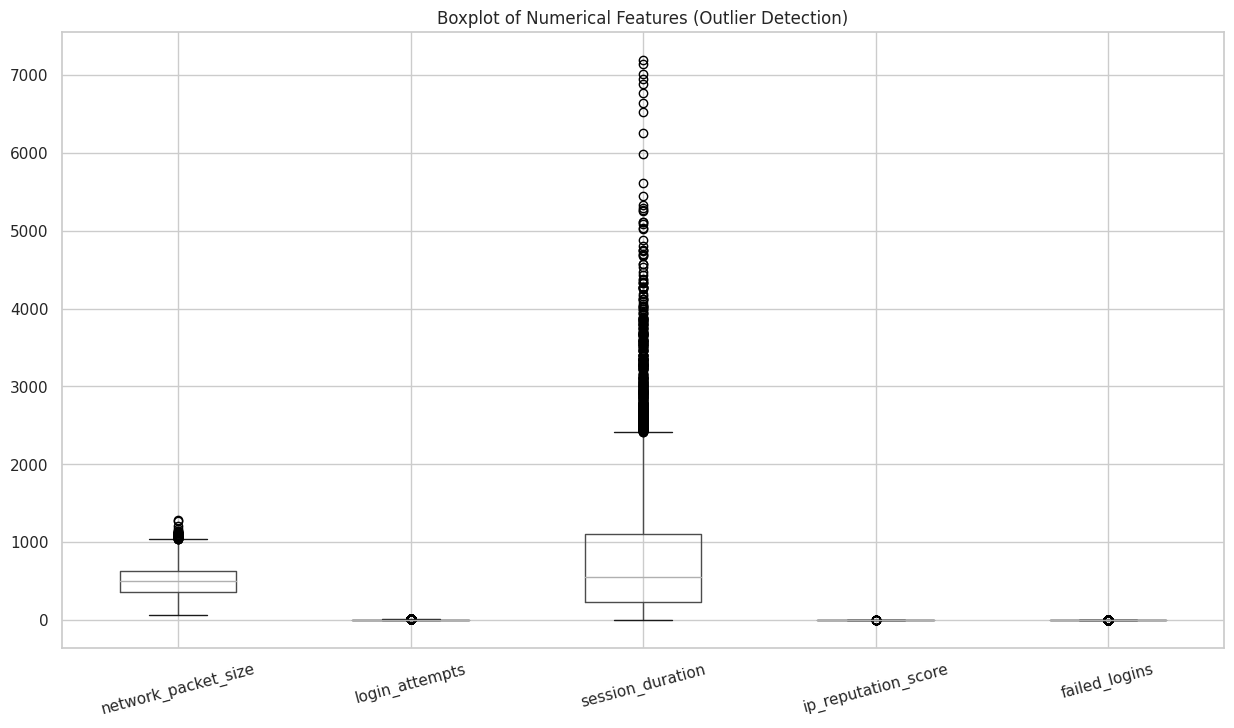

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated a

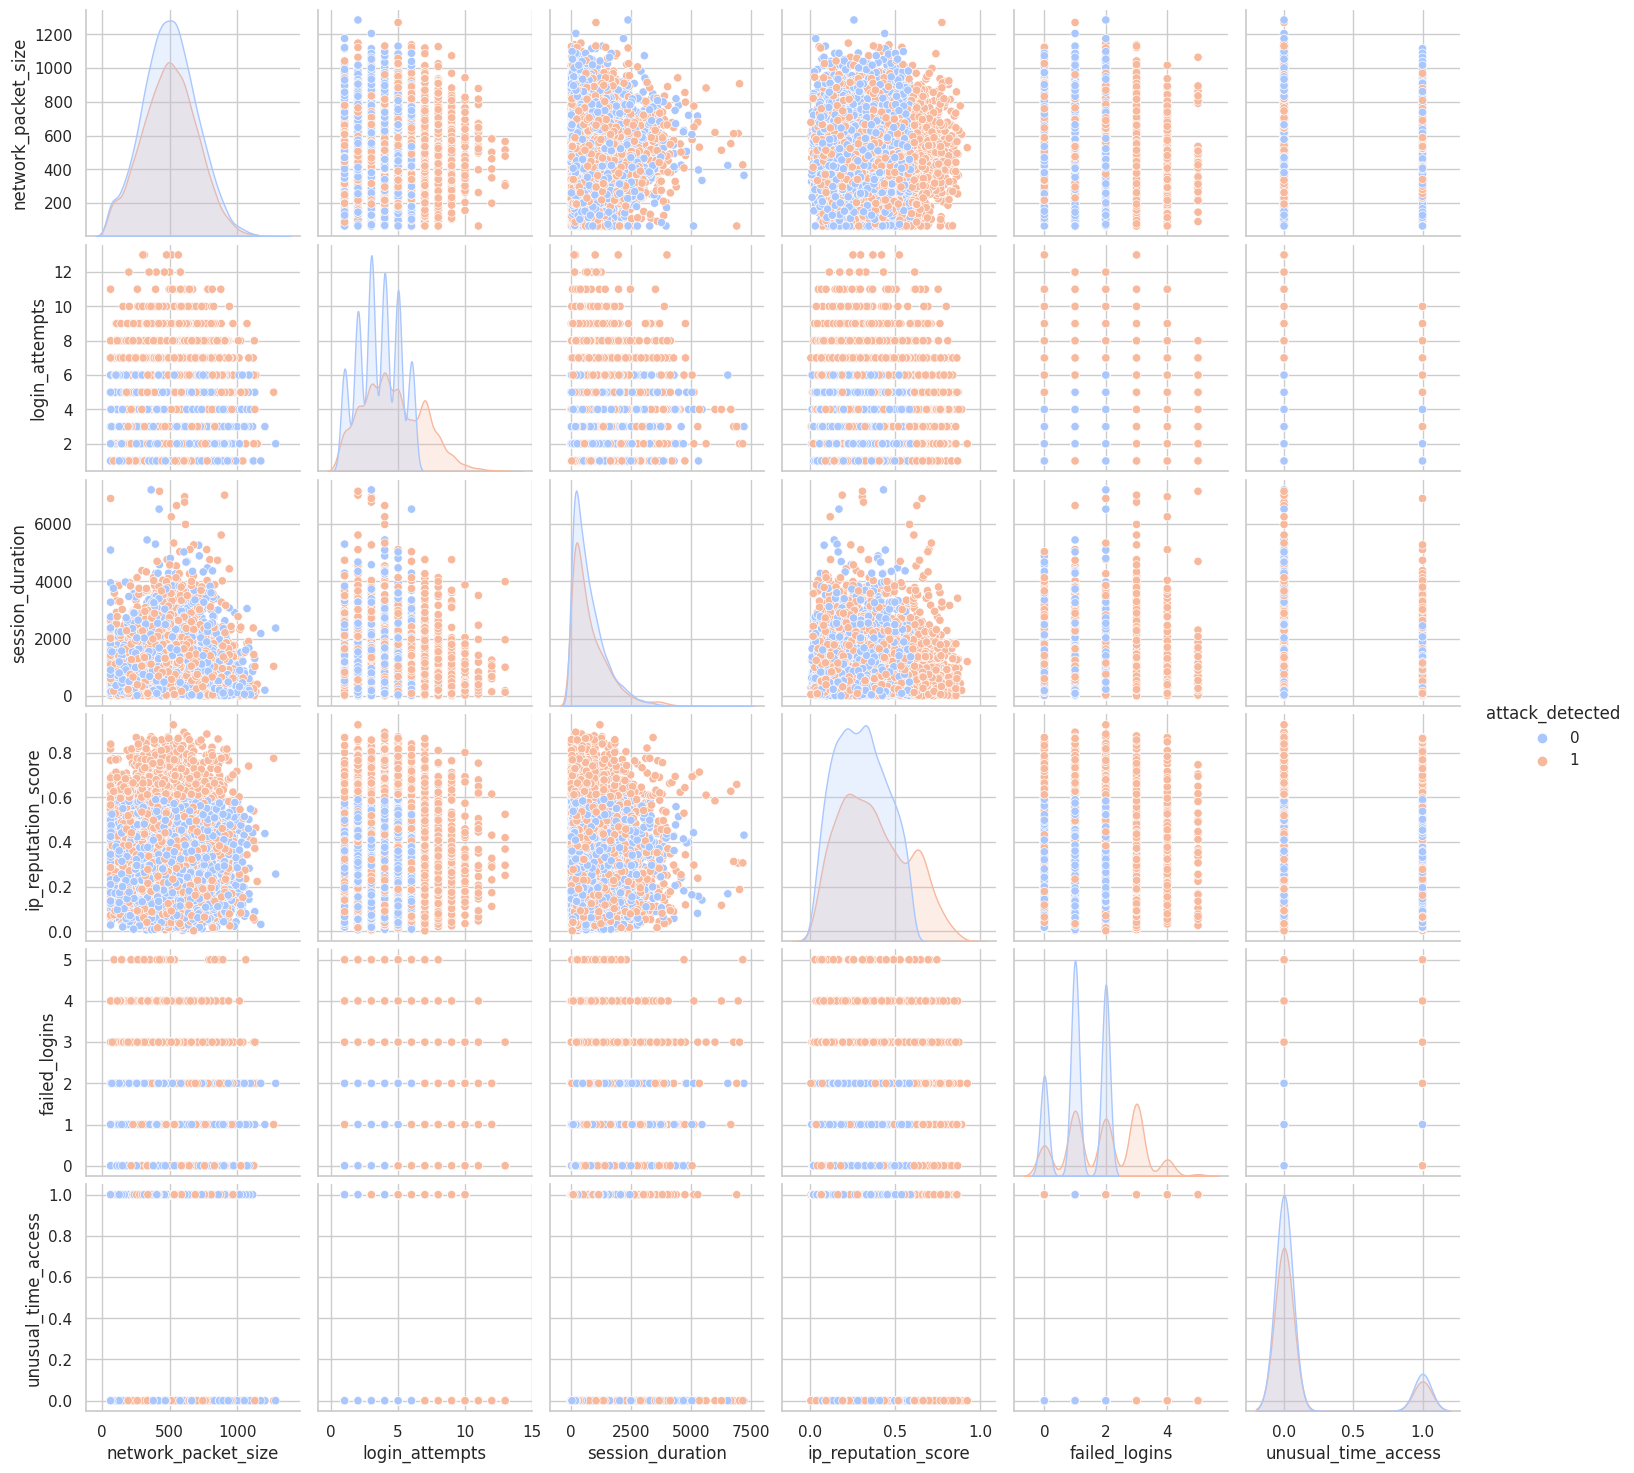

ValueError: could not convert string to float: 'SID_00001'

<Figure size 1000x600 with 0 Axes>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = "/kaggle/input/cybersecurity-intrusion-detection-dataset/cybersecurity_intrusion_data.csv"
df = pd.read_csv(file_path)

# Display dataset info
print(df.info())
print(df.head())

# Set Seaborn style
sns.set(style="whitegrid")

# Numerical features
num_features = ["network_packet_size", "login_attempts", "session_duration", "ip_reputation_score", "failed_logins"]

# Create subplots for numerical feature distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for i, feature in enumerate(num_features):
    row, col = divmod(i, 3)
    sns.histplot(df[feature], kde=True, ax=axes[row, col], bins=30)
    axes[row, col].set_title(f"Distribution of {feature}")

plt.tight_layout()
plt.show()

# Attack vs Normal distribution
plt.figure(figsize=(6, 5))
sns.countplot(x="attack_detected", data=df, palette="coolwarm")
plt.title("Attack vs Normal Distribution")
plt.xticks([0, 1], ["Normal (0)", "Attack (1)"])
plt.show()

# 🔹 Boxplot for Outlier Detection
plt.figure(figsize=(15, 8))
df[num_features].boxplot()
plt.xticks(rotation=15)
plt.title("Boxplot of Numerical Features (Outlier Detection)")
plt.show()

# 🔹 Pairplot to visualize feature relationships
sns.pairplot(df, hue="attack_detected", diag_kind="kde", palette="coolwarm")
plt.show()

# 🔹 Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()



In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Load dataset
file_path = "/kaggle/input/cybersecurity-intrusion-detection-dataset/cybersecurity_intrusion_data.csv"
df = pd.read_csv(file_path)

# Drop session_id if present
if "session_id" in df.columns:
    df.drop(columns=["session_id"], inplace=True)

# Define feature categories
numerical_features = ["network_packet_size", "login_attempts", "session_duration", "ip_reputation_score", "failed_logins"]
categorical_features = ["protocol_type", "encryption_used", "browser_type"]
binary_features = ["unusual_time_access"]  # Already binary, no need for encoding
target_variable = "attack_detected"

# Handle missing values (if any)
df[numerical_features] = df[numerical_features].fillna(df[numerical_features].median())  # Fill numerical NaN with median
df[categorical_features] = df[categorical_features].fillna("Unknown")  # Fill categorical NaN with "Unknown"

# One-Hot Encoding for Categorical Features
df_encoded = pd.get_dummies(df, columns=categorical_features, drop_first=True)

# Define features (X) and target (y)
X = df_encoded.drop(columns=[target_variable])
y = df_encoded[target_variable]

# Train-test split (80-20) with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize numerical features
scaler = StandardScaler()
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = scaler.transform(X_test[numerical_features])

# Print class distribution
print("Class Distribution in Train Set:")
print(y_train.value_counts(normalize=True))

print("Class Distribution in Test Set:")
print(y_test.value_counts(normalize=True))


Class Distribution in Train Set:
attack_detected
0    0.55289
1    0.44711
Name: proportion, dtype: float64
Class Distribution in Test Set:
attack_detected
0    0.552935
1    0.447065
Name: proportion, dtype: float64


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
import numpy as np

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
}

# Train and evaluate models
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else np.zeros_like(y_pred)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob)
    }

# Convert results to DataFrame and display
results_df = pd.DataFrame(results).T
print(results_df)


                     Accuracy  Precision    Recall       AUC
Logistic Regression  0.729036   0.719321  0.645955  0.787600
Random Forest        0.886268   0.996875  0.747948  0.879962
SVM                  0.873690   0.966463  0.743259  0.873028
KNN                  0.801363   0.862385  0.661196  0.835555
XGBoost              0.882075   0.975758  0.754982  0.881253


In [6]:
from sklearn.ensemble import VotingClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# Define ensemble models
xgb = XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)
cat = CatBoostClassifier(verbose=0, random_state=42)
lgb = LGBMClassifier(random_state=42)

# Voting classifier (hard voting)
voting_clf = VotingClassifier(estimators=[("XGBoost", xgb), ("CatBoost", cat), ("LightGBM", lgb)], voting="soft")
voting_clf.fit(X_train, y_train)

# Predict & Evaluate
y_pred = voting_clf.predict(X_test)
y_prob = voting_clf.predict_proba(X_test)[:, 1]

# Compute metrics
ensemble_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "AUC": roc_auc_score(y_test, y_prob),
}

print("Ensemble Model Performance:")
print(pd.DataFrame([ensemble_results], index=["Ensemble"]))


[LightGBM] [Info] Number of positive: 3411, number of negative: 4218
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003098 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 804
[LightGBM] [Info] Number of data points in the train set: 7629, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.447110 -> initscore=-0.212356
[LightGBM] [Info] Start training from score -0.212356
Ensemble Model Performance:
          Accuracy  Precision    Recall       AUC
Ensemble  0.884696   0.992224  0.747948  0.879383


In [7]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Define base models
base_models = [
    ("Random Forest", RandomForestClassifier(n_estimators=100, random_state=42)),
    ("SVM", SVC(probability=True, random_state=42)),
    ("KNN", KNeighborsClassifier(n_neighbors=5)),
    ("XGBoost", XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)),
    ("CatBoost", CatBoostClassifier(verbose=0, random_state=42)),
    ("LightGBM", LGBMClassifier(random_state=42))
]

# Define stacking model
stacking_clf = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression())
stacking_clf.fit(X_train, y_train)

# Predict & Evaluate
y_pred = stacking_clf.predict(X_test)
y_prob = stacking_clf.predict_proba(X_test)[:, 1]

# Compute metrics
stacking_results = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "AUC": roc_auc_score(y_test, y_prob),
}

print("Stacking Model Performance:")
print(pd.DataFrame([stacking_results], index=["Stacking"]))


[LightGBM] [Info] Number of positive: 3411, number of negative: 4218
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000271 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 804
[LightGBM] [Info] Number of data points in the train set: 7629, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.447110 -> initscore=-0.212356
[LightGBM] [Info] Start training from score -0.212356
[LightGBM] [Info] Number of positive: 2729, number of negative: 3374
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000132 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 804
[LightGBM] [Info] Number of data points in the train set: 6103, number of used features: 14
[LightGBM] [Info] [binary:

Base Model Results:
                     Accuracy  Precision    Recall       AUC
Logistic Regression  0.729036   0.719321  0.645955  0.787600
Random Forest        0.886268   0.996875  0.747948  0.879962
SVM                  0.873690   0.966463  0.743259  0.873028
KNN                  0.801363   0.862385  0.661196  0.835555
XGBoost              0.882075   0.975758  0.754982  0.881253

Full Model Performance Comparison:
                     Accuracy  Precision    Recall       AUC
Logistic Regression  0.729036   0.719321  0.645955  0.787600
Random Forest        0.886268   0.996875  0.747948  0.879962
SVM                  0.873690   0.966463  0.743259  0.873028
KNN                  0.801363   0.862385  0.661196  0.835555
XGBoost              0.882075   0.975758  0.754982  0.881253
Ensemble             0.884696   0.992224  0.747948  0.879383
Stacking             0.884172   0.989164  0.749121  0.873929


<Figure size 1200x600 with 0 Axes>

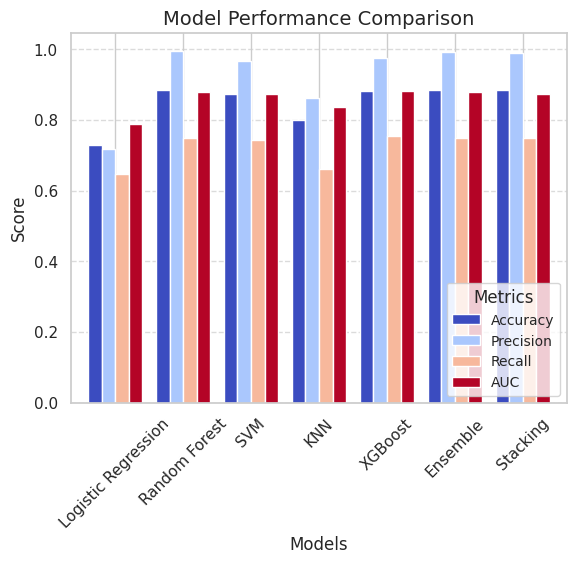

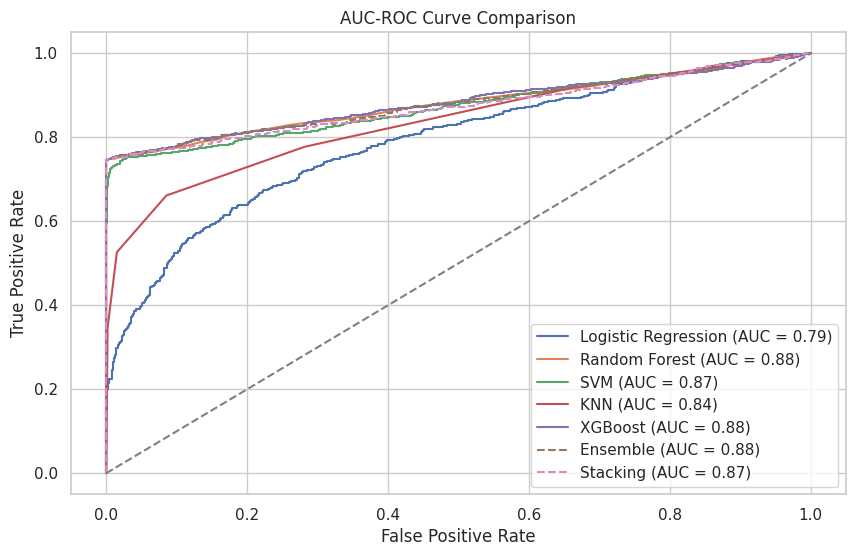

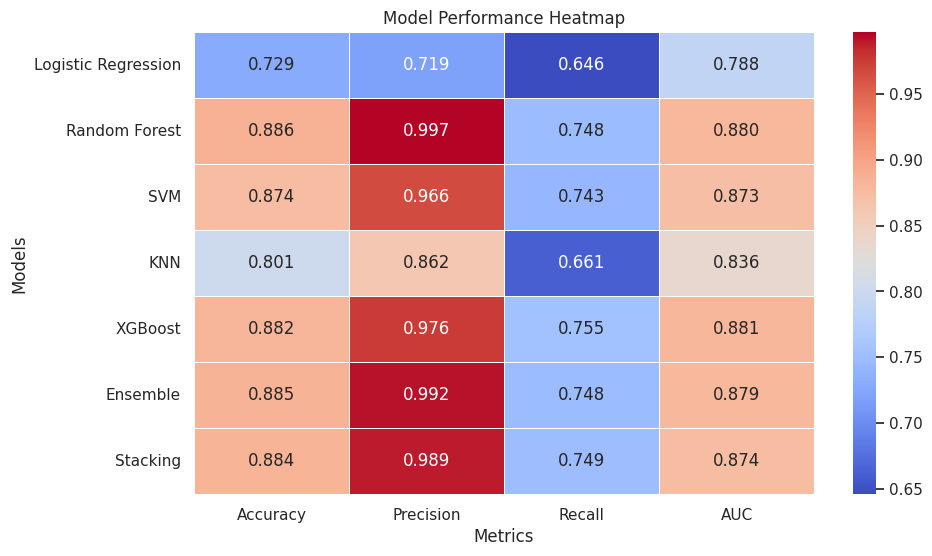

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# Convert base model results dictionary to DataFrame
results_df = pd.DataFrame(results).T
print("Base Model Results:")
print(results_df)

# Add Ensemble and Stacking Results
all_results = results_df.copy()
all_results.loc["Ensemble"] = ensemble_results
all_results.loc["Stacking"] = stacking_results

# Display full comparison table
print("\nFull Model Performance Comparison:")
print(all_results)

# ----------------------------- #
# 1️⃣ Bar Plot: Model Performance
# ----------------------------- #
plt.figure(figsize=(12, 6))
all_results.plot(kind="bar", colormap="coolwarm", rot=45, width=0.8)

# Enhancing aesthetics
plt.title("Model Performance Comparison", fontsize=14)
plt.ylabel("Score", fontsize=12)
plt.xlabel("Models", fontsize=12)
plt.xticks(rotation=45)
plt.legend(title="Metrics", loc="lower right", fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show plot
plt.show()

# ----------------------------- #
# 2️⃣ AUC-ROC Curve for All Models
# ----------------------------- #
plt.figure(figsize=(10, 6))

# Loop through models to plot ROC curve
for model_name, model in models.items():
    y_pred_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else np.zeros_like(y_test)
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.2f})")

# Include ensemble models
for model_name, clf in [("Ensemble", voting_clf), ("Stacking", stacking_clf)]:
    y_pred_prob = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linestyle="--", label=f"{model_name} (AUC = {roc_auc:.2f})")

# Plot aesthetics
plt.plot([0, 1], [0, 1], color="gray", linestyle="--")  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)

# Show plot
plt.show()

# ----------------------------- #
# 3️⃣ Heatmap: Model Performance
# ----------------------------- #
plt.figure(figsize=(10, 6))
sns.heatmap(all_results, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".3f")

plt.title("Model Performance Heatmap")
plt.ylabel("Models")
plt.xlabel("Metrics")

# Show heatmap
plt.show()
